# Linear Regression (Python Lab-Lecture)
## Applied to Particle Physics: The TrackML Challenge at the LHC
### Computational Methods — UCG2RM04
---

> **Context — What is TrackML?**  
> At the Large Hadron Collider (LHC) at CERN, two bunches of protons collide ~40 million times per second.  
> Each collision produces thousands of charged particles that spiral outward through layers of silicon detectors, leaving tiny 3D "hit" signals.  
> The **TrackML Particle Tracking Challenge** asked: *can machine learning reconstruct which hits belong to the same particle track?*
>
> **In this notebook we zoom in on one fundamental sub-problem**: given the (x, y, z) hit positions of a single charged particle traveling through the detector, fit a straight line to each 2D projection — this is *exactly* what tracking algorithms call a **track seed**.

---

### Topics covered
| # | Section | Key concept |
|---|---------|-------------|
| 1 | Scatter plots | Visualising detector hits |
| 2 | Criteria for a best fit | Why least squares? |
| 3 | Least-squares fit of a straight line | Deriving & computing b and a |
| 4 | Quantification of error | SE, RMSE, residual std |
| 5 | Linear regression (full) | numpy, sklearn, interpretation |
| 6 | Linearisation of nonlinear relationships | Helix → linear transform |

---

**Prerequisites:** basic Python, numpy, matplotlib  
**Dataset:** synthetic TrackML-style data generated

In [1]:
# ── Standard imports ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Style
# Notebook-wide style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12,
})

BLUE  = '#2471A3'
RED   = '#C0392B'
GREEN = '#1E8449'
GOLD  = '#D4AC0D'
WHITE = '#E8F4FD'

np.random.seed(42)
print('Environment ready.')

Environment ready.


---
## 🔬 Generating Realistic TrackML-Style Data

In the real TrackML dataset each event contains ~100,000 3D hits from ~10,000 tracks.

Below we simulate a **single proton–proton collision** producing 50 charged particles.  
Each particle travels along a **helix** (straight line + curvature from the LHC magnetic field),  
leaving hits in 9 detector layers. Detector noise adds Gaussian smearing to each hit position.

The data tables mirror the real TrackML CSV files:

| Table | Columns | Description |
|-------|---------|-------------|
| `hits` | `hit_id, x, y, z, volume_id, layer_id` | Measured 3D positions |
| `truth` | `hit_id, particle_id, tx, ty, tz` | True (noiseless) positions + particle label |
| `particles` | `particle_id, px, py, pz, q, nhits` | Particle momentum & charge |

In [2]:
def simulate_trackml_event(n_particles=50, n_layers=9, hit_noise_mm=0.05, seed=42):
    """
    Simulate one LHC collision event in the style of the TrackML dataset.
    
    Geometry:
      - Cylindrical silicon tracker, radii 30-300 mm, z in [-500, 500] mm
      - Magnetic field B = 2 T along z-axis  →  particles curve in the x-y plane
      - Each particle is a helix parameterised by (pt, eta, phi, q, vz)
    """
    rng = np.random.default_rng(seed)
    radii = np.linspace(30, 300, n_layers)          # detector layer radii [mm]

    hit_records      = []
    truth_records    = []
    particle_records = []

    for pid in range(1, n_particles + 1):
        # Particle kinematics (typical LHC collision)
        pt  = rng.uniform(0.5, 10.0)         # transverse momentum [GeV/c]
        eta = rng.uniform(-2.5, 2.5)         # pseudorapidity
        phi = rng.uniform(0, 2 * np.pi)      # azimuthal angle
        q   = rng.choice([-1, 1])            # charge
        vz  = rng.uniform(-5, 5)             # z vertex [mm]

        # 3-momentum components
        pz = pt * np.sinh(eta)
        px = pt * np.cos(phi)
        py = pt * np.sin(phi)

        # Helix radius in the B-field (B=2T, p in GeV/c → r [mm])
        B   = 2.0
        r_h = pt * 1000 / (0.3 * B)          # helix radius [mm]
        # Centre of the helix circle
        cx = -q * r_h * np.sin(phi)
        cy =  q * r_h * np.cos(phi)

        particle_records.append(dict(particle_id=pid, px=px, py=py, pz=pz,
                                     q=q, pt=pt, eta=eta, nhits=n_layers))

        for layer_id, r_det in enumerate(radii, start=1):
            # Intersection of helix circle with detector cylinder
            # d = distance from helix centre to cylinder axis
            d = np.sqrt(cx**2 + cy**2)       # = r_h (track starts at origin)
            # Angle to the intersection point
            cos_angle = (d**2 + r_h**2 - r_det**2) / (2 * d * r_h) if d > 0 else 0
            cos_angle = np.clip(cos_angle, -1, 1)
            delta     = np.arccos(cos_angle)
            # True hit angle in x-y plane
            theta_c = np.arctan2(cy, cx)
            hit_phi = theta_c + q * delta
            # True hit (x, y, z)
            tx = r_det * np.cos(hit_phi)
            ty = r_det * np.sin(hit_phi)
            # z: use the helix pitch (dz/dphi proportional to pz/pt)
            arc_length = r_h * abs(delta)
            tz = vz + pz / pt * arc_length

            # Measured hit = truth + Gaussian detector noise
            hx = tx + rng.normal(0, hit_noise_mm)
            hy = ty + rng.normal(0, hit_noise_mm)
            hz = tz + rng.normal(0, hit_noise_mm)

            hit_id = (pid - 1) * n_layers + layer_id
            hit_records.append(dict(hit_id=hit_id, x=hx, y=hy, z=hz,
                                    volume_id=1, layer_id=layer_id))
            truth_records.append(dict(hit_id=hit_id, particle_id=pid,
                                      tx=tx, ty=ty, tz=tz))

    hits      = pd.DataFrame(hit_records)
    truth     = pd.DataFrame(truth_records)
    particles = pd.DataFrame(particle_records)
    return hits, truth, particles


hits, truth, particles = simulate_trackml_event(n_particles=50, n_layers=9)

print('=== hits (first 5 rows) ===')
print(hits.head())
print(f'\nTotal hits: {len(hits)}')
print(f'\n=== particles (first 5 rows) ===')
print(particles.head())

=== hits (first 5 rows) ===
   hit_id           x           y          z  volume_id  layer_id
0       1  -23.391373  -18.858533 -13.385656          1         1
1       2  -49.672365  -40.002659 -23.801458          1         2
2       3  -76.086675  -60.915894 -34.264683          1         3
3       4 -102.664484  -81.785035 -44.778275          1         4
4       5 -129.405825 -102.384289 -55.274944          1         5

Total hits: 450

=== particles (first 5 rows) ===
   particle_id        px        py        pz  q        pt       eta  nhits
0            1  4.951929 -6.094379 -2.437341 -1  7.852582 -0.305608      9
1            2 -3.529764  0.683554 -2.494979  1  3.595341 -0.647701      9
2            3 -1.915006  5.431287  1.729883  1  5.759004  0.296036      9
3            4  1.294666 -0.316009 -4.401027 -1  1.332674 -1.909970      9
4            5  0.709272  1.301626  0.670582 -1  1.482328  0.438223      9


---
## Section 1 — Scatter Plots
### Visualising Detector Hits

The first thing any physicist (or data scientist) does: **plot the data**.  
A scatter plot shows every measured point in space without assumptions.

We will look at:
1. All hits in the event (the full fireworks picture)
2. Hits from a single selected particle track
3. The r–z projection (a standard tracking diagnostic)

**Key variable: cylindrical radius**
$$r = \sqrt{x^2 + y^2}$$
In a cylindrical detector, r is the distance from the beam axis.

In [3]:
# ── Compute cylindrical radius for all hits ──────────────────────────────────
hits['r'] = np.sqrt(hits['x']**2 + hits['y']**2)
truth['r'] = np.sqrt(truth['tx']**2 + truth['ty']**2)

# Select one "nice" particle: high-pt, central (|eta| < 1)
central = particles[(particles['pt'] > 2) & (np.abs(particles['eta']) < 1)]
selected_pid = central.iloc[2]['particle_id']
track_hits  = hits.merge(truth[truth.particle_id == selected_pid][['hit_id']], on='hit_id')
track_truth = truth[truth.particle_id == selected_pid]
sel_particle = particles[particles.particle_id == selected_pid].iloc[0]

print(f'Selected particle: id={int(selected_pid)},  pt={sel_particle.pt:.2f} GeV/c,'
      f'  eta={sel_particle.eta:.2f},  charge q={int(sel_particle.q)}')

Selected particle: id=3,  pt=5.76 GeV/c,  eta=0.30,  charge q=1


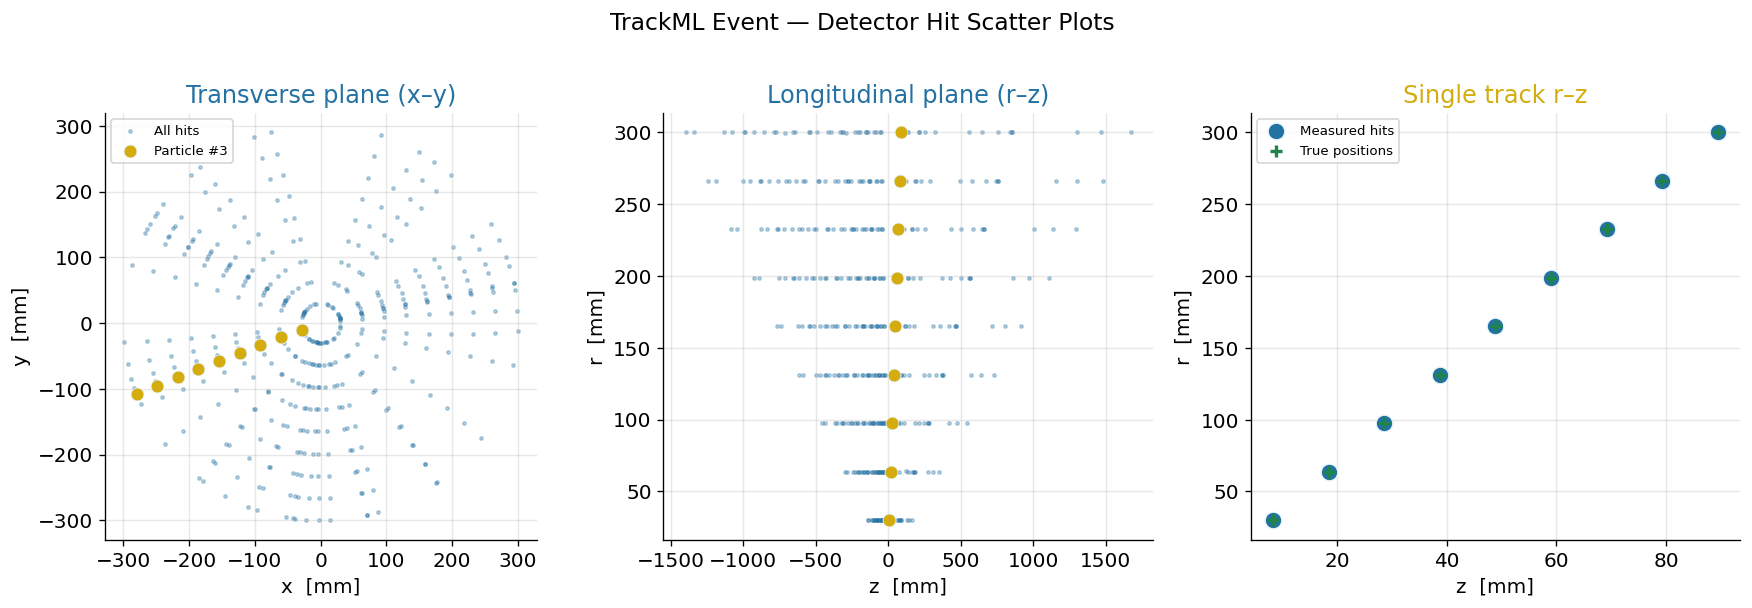


Fig 1 saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('TrackML Event — Detector Hit Scatter Plots', fontsize=14, y=1.01)

# ─ Plot 1: x-y view (transverse plane), all particles ───────────────────────
ax = axes[0]
ax.scatter(hits['x'], hits['y'], s=4, c=BLUE, alpha=0.3, label='All hits')
ax.scatter(track_hits['x'], track_hits['y'], s=60, c=GOLD,
           edgecolors=WHITE, linewidths=0.5, zorder=5, label=f'Particle #{int(selected_pid)}')
ax.set_xlabel('x  [mm]');  ax.set_ylabel('y  [mm]')
ax.set_title('Transverse plane (x–y)', color=BLUE)
ax.set_aspect('equal');  ax.legend(fontsize=8);  ax.grid(True)

# ─ Plot 2: r-z view, all particles ───────────────────────────────────────────
ax = axes[1]
ax.scatter(hits['z'], hits['r'], s=4, c=BLUE, alpha=0.3)
ax.scatter(track_hits['z'], track_hits['r'], s=60, c=GOLD,
           edgecolors=WHITE, linewidths=0.5, zorder=5)
ax.set_xlabel('z  [mm]');  ax.set_ylabel('r  [mm]')
ax.set_title('Longitudinal plane (r–z)', color=BLUE)
ax.grid(True)

# ─ Plot 3: single selected track, r-z projection ─────────────────────────────
ax = axes[2]
ax.scatter(track_hits['z'], track_hits['r'], s=100, c=BLUE,
           edgecolors=WHITE, linewidths=0.8, zorder=5, label='Measured hits')
ax.scatter(track_truth['tz'], track_truth['r'], s=60, c=GREEN,
           marker='+', linewidths=2, zorder=6, label='True positions')
for _, row in track_hits.iterrows():
    tr = track_truth[track_truth.hit_id == row.hit_id].iloc[0]
    ax.plot([row['z'], tr['tz']], [row['r'], tr['r']], c=RED, lw=0.8, alpha=0.7)
ax.set_xlabel('z  [mm]');  ax.set_ylabel('r  [mm]')
ax.set_title(f'Single track r–z', color=GOLD)
ax.legend(fontsize=8);  ax.grid(True)

plt.tight_layout()
plt.savefig('fig1_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nFig 1 saved.')

### 📝 Discussion — Reading the Scatter Plot

| Panel | What you see | Physical meaning |
|-------|-------------|------------------|
| x–y | Dots arranged in rings | Hits in cylindrical detector layers |
| r–z (all) | Fan-shaped spread | Tracks going in all directions |
| r–z (single track) | Points nearly on a straight line | Helix projects to a line in r–z! |

**The key insight**: in the r–z projection, a charged particle track looks *almost perfectly linear*,  
even though it curves in x–y.  
This is because $r$ grows monotonically with the arc length, and $z$ grows proportionally to the pitch.

This is why **linear regression is the first tool** used in particle tracking.

---

### ✏️ Exercise 1.1
Below, select **three** different particles (one low-pₜ, one high-pₜ, one very forward/high |η|).  
Plot their r–z scatter plots side by side. Answer:
- Which particle has the largest r-z slope? Why?
- Which looks most linear? Can you relate this to the helix formula?

Available particles:
 particle_id       pt       eta  q  nhits
           1 7.852582 -0.305608 -1      9
           2 3.595341 -0.647701  1      9
           3 5.759004  0.296036  1      9
           4 1.332674 -1.909970 -1      9
           5 1.482328  0.438223 -1      9
           6 9.202113 -1.348930  1      9
           7 1.666200  1.655563  1      9
           8 5.774381  0.669876 -1      9
           9 8.334310 -0.948327  1      9
          10 9.805921  1.510129  1      9
          11 5.560862  0.664588 -1      9
          12 1.637469 -1.914482  1      9
          13 6.088451  0.930482 -1      9
          14 2.766252  1.747044 -1      9
          15 5.937925 -1.774349  1      9
          16 6.698114 -0.918929 -1      9
          17 3.966734  2.292146 -1      9
          18 5.156877  0.432226  1      9
          19 9.310874 -0.258963 -1      9
          20 9.790211 -0.442120  1      9
          21 3.806299  1.766723  1      9
          22 5.638138 -1.077296  1      9
          23 

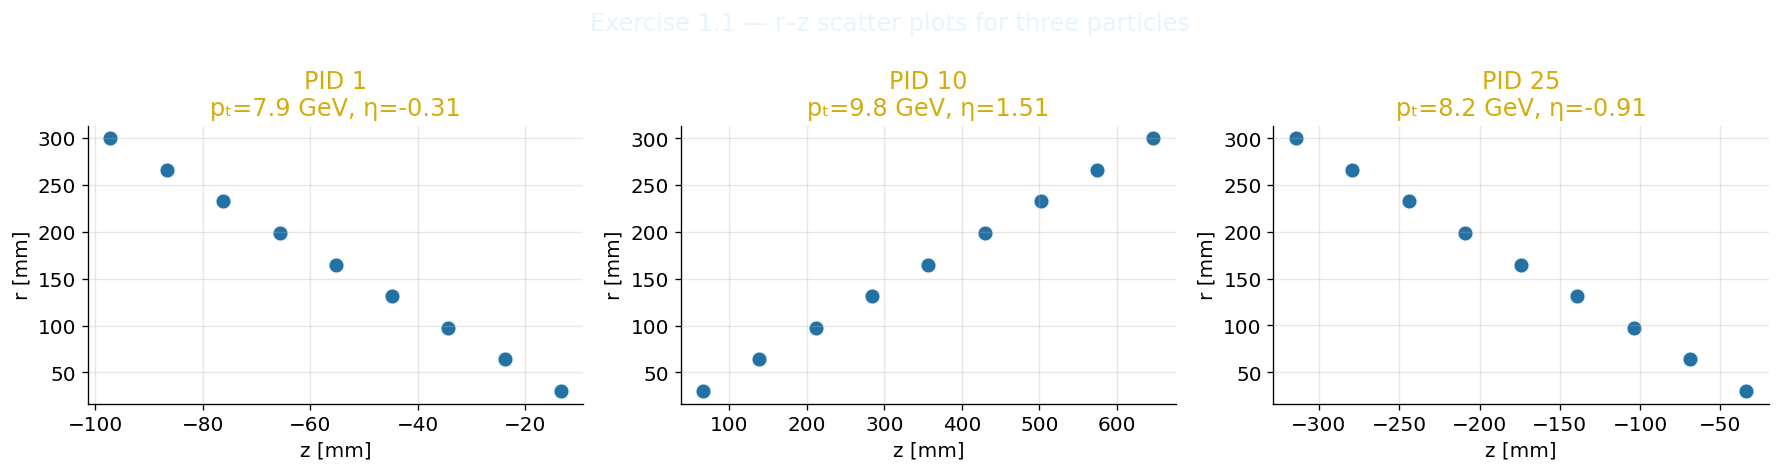

In [5]:
# ── Exercise 1.1 starter ─────────────────────────────────────────────────────
print('Available particles:')
print(particles[['particle_id','pt','eta','q','nhits']].to_string(index=False))

# TODO: pick three particle_ids from the table above
pids_to_plot = [1, 10, 25]   # ← change these

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pid in zip(axes, pids_to_plot):
    t_hits  = hits.merge(truth[truth.particle_id == pid][['hit_id']], on='hit_id')
    pt_val  = particles[particles.particle_id == pid].iloc[0]['pt']
    eta_val = particles[particles.particle_id == pid].iloc[0]['eta']
    ax.scatter(t_hits['z'], t_hits['r'], s=80, c=BLUE, edgecolors=WHITE, linewidths=0.5)
    ax.set_xlabel('z [mm]');  ax.set_ylabel('r [mm]')
    ax.set_title(f'PID {int(pid)}\npₜ={pt_val:.1f} GeV, η={eta_val:.2f}', color=GOLD)
    ax.grid(True)
plt.suptitle('Exercise 1.1 — r–z scatter plots for three particles', color=WHITE)
plt.tight_layout()
plt.show()

---
## Section 3 — Least-Squares Fit of a Straight Line
### Deriving the Formulas From Scratch

We want to minimise:
$$S(a, b) = \sum_{i=1}^{n} (r_i - a - b z_i)^2$$

Setting $\partial S/\partial a = 0$ and $\partial S/\partial b = 0$ yields the **normal equations**:

$$\boxed{b = \frac{\displaystyle\sum_{i=1}^n (z_i - \bar{z})(r_i - \bar{r})}{\displaystyle\sum_{i=1}^n (z_i - \bar{z})^2}}$$

$$\boxed{a = \bar{r} - b\,\bar{z}}$$

where $\bar{z}$ and $\bar{r}$ are the sample means.  
The line always passes through the mean point $(\bar{z},\, \bar{r})$.

In [6]:
# ── Build x, y arrays for our selected track ─────────────────────────────────
z_data = track_hits['z'].values          # independent variable: z position
r_data = track_hits['r'].values          # dependent variable:   r position
n = len(z_data)
print(f'Track has {n} hits')
print(f'z range: [{z_data.min():.1f}, {z_data.max():.1f}] mm')
print(f'r range: [{r_data.min():.1f}, {r_data.max():.1f}] mm')

z_bar = np.mean(z_data)
r_bar = np.mean(r_data)

dz = z_data - z_bar          # deviations from z mean
dr = r_data - r_bar          # deviations from r mean

numerator   = np.sum(dz * dr)   # Σ(zᵢ − z̄)(rᵢ − r̄)
denominator = np.sum(dz**2)     # Σ(zᵢ − z̄)²

b_ls = numerator / denominator
a_ls = r_bar - b_ls * z_bar

# Summary table
print('=== Step-by-step Least Squares Calculation ===')
print(f'n                = {n}')
print(f'z̄  (mean of z)   = {z_bar:.4f} mm')
print(f'r̄  (mean of r)   = {r_bar:.4f} mm')
print(f'Σ(zᵢ−z̄)(rᵢ−r̄)   = {numerator:.6f}')
print(f'Σ(zᵢ−z̄)²        = {denominator:.6f}')
print(f'─────────────────────────────────────────')
print(f'Slope  b = {b_ls:.6f}  mm/mm')
print(f'Intercept a = {a_ls:.4f}  mm')
print(f'Fitted line: r̂ = {a_ls:.4f} + {b_ls:.6f} · z')

# Verify with numpy
b_np, a_np = np.polyfit(z_data, r_data, 1)
print(f'\nVerification via np.polyfit: b={b_np:.6f}, a={a_np:.4f}')
assert np.isclose(b_ls, b_np, rtol=1e-8), 'Mismatch!'
print('✓ Manual calculation matches numpy.')

Track has 9 hits
z range: [8.3, 89.4] mm
r range: [30.0, 300.0] mm
=== Step-by-step Least Squares Calculation ===
n                = 9
z̄  (mean of z)   = 48.9158 mm
r̄  (mean of r)   = 165.0038 mm
Σ(zᵢ−z̄)(rᵢ−r̄)   = 20529.182611
Σ(zᵢ−z̄)²        = 6166.188187
─────────────────────────────────────────
Slope  b = 3.329315  mm/mm
Intercept a = 2.1477  mm
Fitted line: r̂ = 2.1477 + 3.329315 · z

Verification via np.polyfit: b=3.329315, a=2.1477
✓ Manual calculation matches numpy.


In [7]:
# ── Visualise the computation table ─────────────────────────────────────────
df_calc = pd.DataFrame({
    'zᵢ':          np.round(z_data, 3),
    'rᵢ':          np.round(r_data, 3),
    'zᵢ − z̄':      np.round(dz, 4),
    'rᵢ − r̄':      np.round(dr, 4),
    '(zᵢ−z̄)(rᵢ−r̄)': np.round(dz * dr, 6),
    '(zᵢ−z̄)²':     np.round(dz**2, 6),
})
df_calc.index.name = 'hit'
df_calc.loc['Σ'] = ['', '', '', '', round(numerator, 6), round(denominator, 6)]
print(df_calc.to_string())
print(f'\nb = {numerator:.6f} / {denominator:.6f} = {b_ls:.6f}')
print(f'a = {r_bar:.4f} − {b_ls:.6f} × {z_bar:.4f} = {a_ls:.4f}')

         zᵢ       rᵢ  zᵢ − z̄   rᵢ − r̄  (zᵢ−z̄)(rᵢ−r̄)     (zᵢ−z̄)²
hit                                                                 
0     8.315   29.963 -40.6011  -135.041     5482.806355  1648.445533
1    18.541   63.819 -30.3746 -101.1849     3073.450542   922.616125
2    28.633   97.482 -20.2829  -67.5223     1369.550828   411.397813
3    38.777  131.232 -10.1391   -33.772      342.417501   102.801036
4    48.912   164.99  -0.0037   -0.0137        0.000050     0.000014
5    59.093  198.789  10.1771   33.7851      343.833111   103.572475
6    69.231  232.522  20.3152   67.5179     1371.638019   412.706078
7    79.341  266.217  30.4248  101.2134     3079.403300   925.671293
8      89.4  300.021  40.4843  135.0174     5466.082907  1638.977820
Σ                                          20529.182611  6166.188187

b = 20529.182611 / 6166.188187 = 3.329315
a = 165.0038 − 3.329315 × 48.9158 = 2.1477


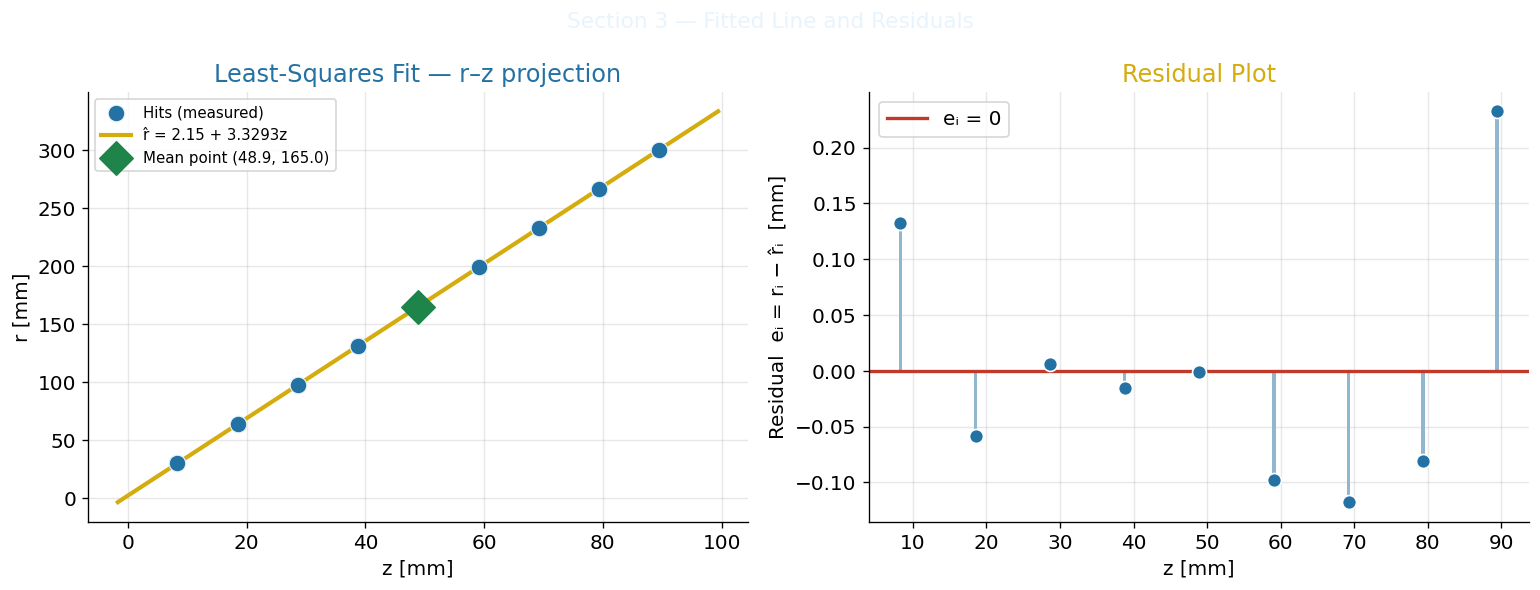

In [8]:
# ── Final fitted-line plot ───────────────────────────────────────────────────
z_fit = np.linspace(z_data.min() - 10, z_data.max() + 10, 300)
r_fit = a_ls + b_ls * z_fit
r_pred = a_ls + b_ls * z_data
residuals = r_data - r_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter + fit
ax = axes[0]
ax.scatter(z_data, r_data, s=100, c=BLUE, edgecolors=WHITE, lw=0.7, zorder=5, label='Hits (measured)')
ax.plot(z_fit, r_fit, c=GOLD, lw=2.5, label=f'r̂ = {a_ls:.2f} + {b_ls:.4f}z')
ax.scatter(z_bar, r_bar, s=200, c=GREEN, marker='D', zorder=6, label=f'Mean point ({z_bar:.1f}, {r_bar:.1f})')
for zi, ri, rp in zip(z_data, r_data, r_pred):
    ax.plot([zi, zi], [ri, rp], c=RED, lw=1.5, alpha=0.8)
ax.set_xlabel('z [mm]');  ax.set_ylabel('r [mm]')
ax.set_title('Least-Squares Fit — r–z projection', color=BLUE)
ax.legend(fontsize=9);  ax.grid(True)

# Right: residuals
ax = axes[1]
ax.axhline(0, c=RED, lw=2, ls='-', label='eᵢ = 0')
ax.scatter(z_data, residuals, color=BLUE, s=70, zorder=4, edgecolors='white')
ax.bar(z_data, residuals, width=0.5, color=BLUE, alpha=0.5)
ax.set_xlabel('z [mm]');  ax.set_ylabel('Residual  eᵢ = rᵢ − r̂ᵢ  [mm]')
ax.set_title('Residual Plot', color=GOLD)
ax.legend();  ax.grid(True)

plt.suptitle('Section 3 — Fitted Line and Residuals', color=WHITE, fontsize=13)
plt.tight_layout()
plt.savefig('fig3_fit.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 5 — Linear Regression (Full Framework)

So far we computed the least-squares fit manually.  
Now we use the full statistical framework: **scipy.stats** and **sklearn**,  
which also give confidence intervals, t-tests, and p-values.

### The Regression Model
$$r_i = a + b\,z_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,\, \sigma^2)$$

Assumptions:
1. **Linearity**: the true relationship is linear
2. **Independence**: hits on different layers are independent
3. **Homoscedasticity**: measurement noise is the same at all z
4. **Normality** of residuals (needed for t-tests)

In tracking, all four hold approximately — the LHC detector was designed this way.

In [9]:
# ── scipy.stats.linregress ───────────────────────────────────────────────────
result = stats.linregress(z_data, r_data)

print('=== scipy.stats.linregress output ===')
print(f'slope          b = {result.slope:.6f}  ±  {result.stderr:.6f}  mm/mm')
print(f'intercept      a = {result.intercept:.4f}  ±  {result.intercept_stderr:.4f}  mm')
print(f'R²               = {result.rvalue**2:.8f}')
print(f'p-value (slope)  = {result.pvalue:.2e}')
print(f'standard error   = {result.stderr:.6f}')

# 95% confidence interval for slope
t_crit = stats.t.ppf(0.975, df=n-2)
b_ci_lo = result.slope - t_crit * result.stderr
b_ci_hi = result.slope + t_crit * result.stderr
print(f'\n95% CI for slope: [{b_ci_lo:.6f},  {b_ci_hi:.6f}]')

=== scipy.stats.linregress output ===
slope          b = 3.329315  ±  0.001561  mm/mm
intercept      a = 2.1477  ±  0.0866  mm
R²               = 0.99999846
p-value (slope)  = 1.31e-21
standard error   = 0.001561

95% CI for slope: [3.325624,  3.333006]


---
## Section 6 — Linearisation of Nonlinear Relationships

### 6.1 — Radioactive Decay

As a warm-up, we also linearise the exponential decay law:
$$N(t) = N_0 \, e^{-\lambda t} \quad \xrightarrow{\ln} \quad \ln N = \ln N_0 - \lambda t$$

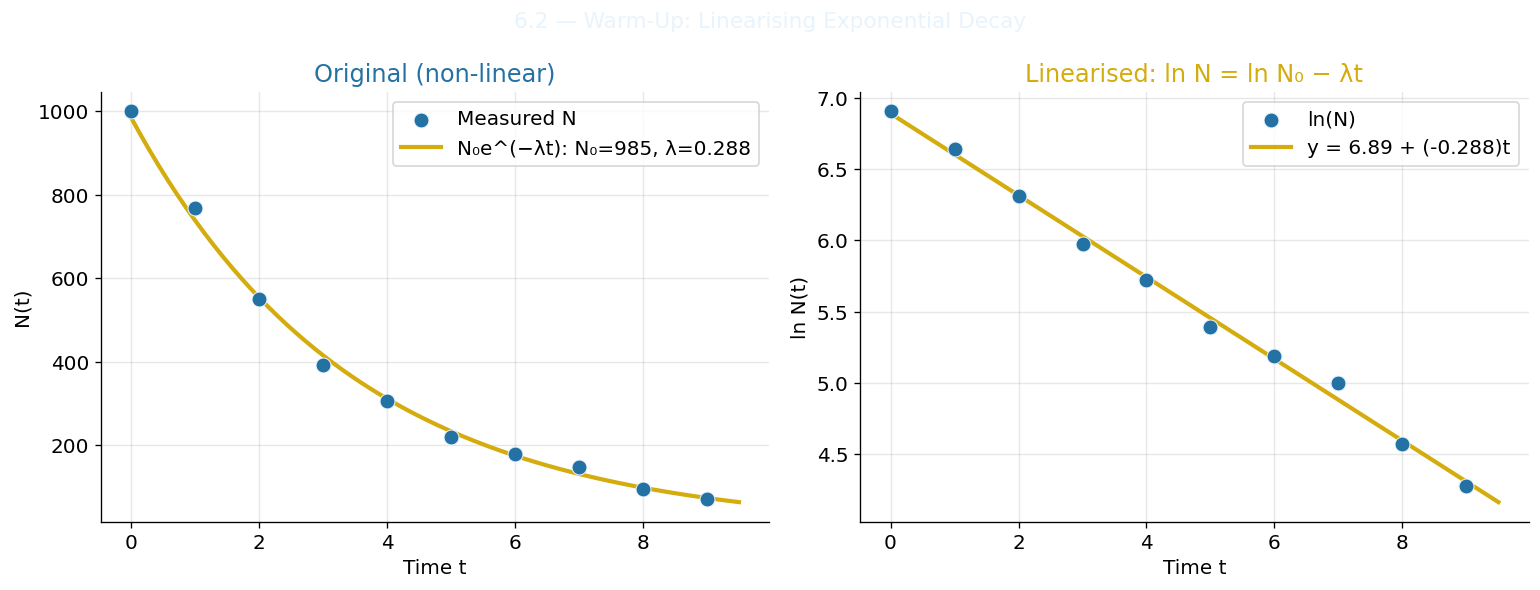

True:    λ = 0.287,  N₀ = 1000,  t½ = 2.415
Fitted:  λ = 0.288,  N₀ = 985,  t½ = 2.410


In [10]:
# ── 6.2 Warm-up: Exponential decay linearisation ─────────────────────────────
rng2 = np.random.default_rng(7)
N0, lam = 1000.0, 0.287
t_decay = np.arange(0, 10)
N_true  = N0 * np.exp(-lam * t_decay)
N_meas  = N_true * (1 + rng2.normal(0, 0.08, size=len(t_decay)))   # 8% noise
N_meas  = np.maximum(N_meas, 1)   # no negatives

lnN = np.log(N_meas)
b_decay, a_decay = np.polyfit(t_decay, lnN, 1)
lam_fit = -b_decay
N0_fit  = np.exp(a_decay)
half_life = np.log(2) / lam_fit

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('6.2 — Warm-Up: Linearising Exponential Decay', color=WHITE, fontsize=13)

ax = axes[0]
t_fine = np.linspace(0, 9.5, 200)
ax.scatter(t_decay, N_meas, s=80, c=BLUE, edgecolors=WHITE, lw=0.6, zorder=5, label='Measured N')
ax.plot(t_fine, N0_fit * np.exp(-lam_fit * t_fine), c=GOLD, lw=2.5,
        label=f'N₀e^(−λt): N₀={N0_fit:.0f}, λ={lam_fit:.3f}')
ax.set_xlabel('Time t');  ax.set_ylabel('N(t)')
ax.set_title('Original (non-linear)', color=BLUE);  ax.legend();  ax.grid(True)

ax = axes[1]
ax.scatter(t_decay, lnN, s=80, c=BLUE, edgecolors=WHITE, lw=0.6, zorder=5, label='ln(N)')
ax.plot(t_fine, a_decay + b_decay * t_fine, c=GOLD, lw=2.5,
        label=f'y = {a_decay:.2f} + ({b_decay:.3f})t')
ax.set_xlabel('Time t');  ax.set_ylabel('ln N(t)')
ax.set_title('Linearised: ln N = ln N₀ − λt', color=GOLD)
ax.legend();  ax.grid(True)

plt.tight_layout()
plt.show()
print(f'True:    λ = {lam:.3f},  N₀ = {N0:.0f},  t½ = {np.log(2)/lam:.3f}')
print(f'Fitted:  λ = {lam_fit:.3f},  N₀ = {N0_fit:.0f},  t½ = {half_life:.3f}')

### ✏️ Exercise 6.1 — Power Law

A common relationship in detector physics is a **power law**: $y = a\,x^b$.

Taking logarithms of both sides:
$$\ln y = \ln a + b \ln x$$

This is linear in $(\ln x, \ln y)$.

**Task:** The energy deposit (charge) in a silicon strip detector scales with path length $L$ (in mm) as $E = a\,L^b$ (the Bethe–Bloch plateau).  
Use the data below to find $a$ and $b$ via log-log linearisation.

=== Power Law Fit via Log-Log Linearisation ===
True:    a = 15.00,  b = 1.20
Fitted:  a = 15.03,   b = 1.21


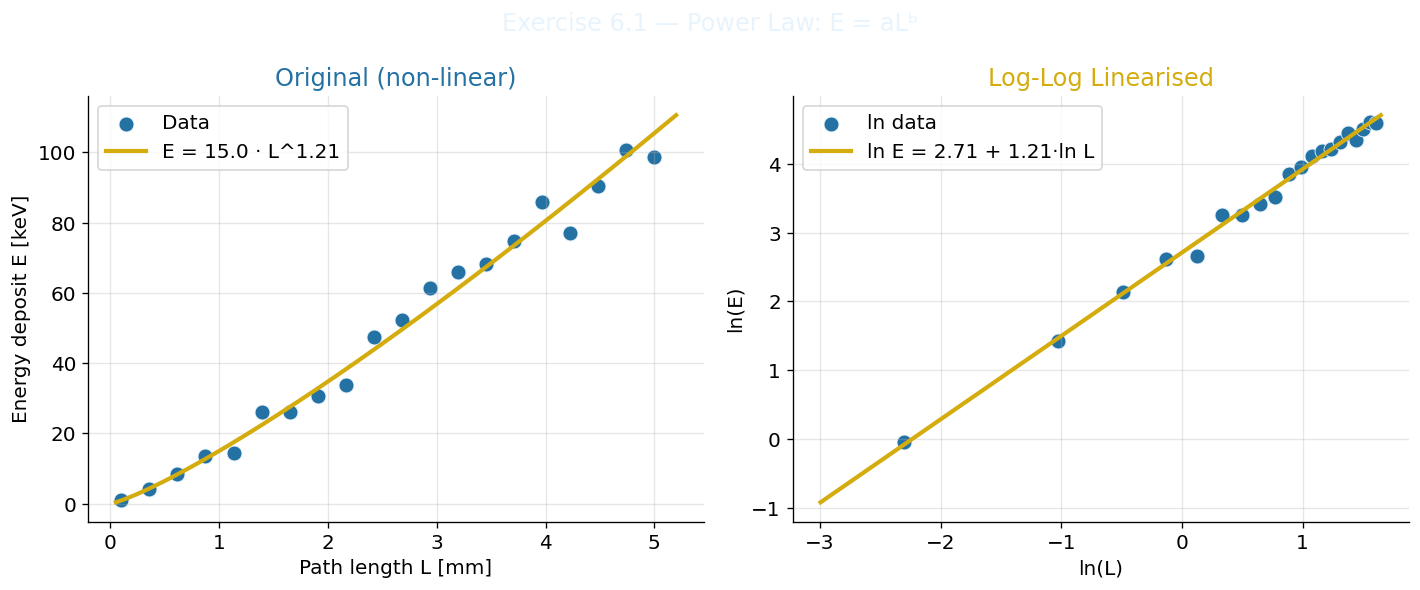

In [11]:
# ── Exercise 6.1 — Power law fit ─────────────────────────────────────────────
# Simulated energy deposit data (a=15, b=1.2, 10% noise)
rng3    = np.random.default_rng(99)
a_true  = 15.0;   b_true_pw = 1.2
L_vals  = np.linspace(0.1, 5.0, 20)
E_vals  = a_true * L_vals**b_true_pw * (1 + rng3.normal(0, 0.10, 20))

# TODO: Apply log-log linearisation
# Step 1: compute ln(L) and ln(E)
lnL = np.log(L_vals)
lnE = np.log(E_vals)

# Step 2: fit ln(E) = ln(a) + b·ln(L)
b_pw, lna_pw = np.polyfit(lnL, lnE, 1)
a_pw = np.exp(lna_pw)

print('=== Power Law Fit via Log-Log Linearisation ===')
print(f'True:    a = {a_true:.2f},  b = {b_true_pw:.2f}')
print(f'Fitted:  a = {a_pw:.2f},   b = {b_pw:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
L_fine = np.linspace(0.05, 5.2, 200)
ax.scatter(L_vals, E_vals, s=80, c=BLUE, edgecolors=WHITE, lw=0.5, label='Data')
ax.plot(L_fine, a_pw * L_fine**b_pw, c=GOLD, lw=2.5, label=f'E = {a_pw:.1f} · L^{b_pw:.2f}')
ax.set_xlabel('Path length L [mm]');  ax.set_ylabel('Energy deposit E [keV]')
ax.set_title('Original (non-linear)', color=BLUE);  ax.legend();  ax.grid(True)

ax = axes[1]
ax.scatter(lnL, lnE, s=80, c=BLUE, edgecolors=WHITE, lw=0.5, label='ln data')
ax.plot(np.log(L_fine), lna_pw + b_pw * np.log(L_fine), c=GOLD, lw=2.5,
        label=f'ln E = {lna_pw:.2f} + {b_pw:.2f}·ln L')
ax.set_xlabel('ln(L)');  ax.set_ylabel('ln(E)')
ax.set_title('Log-Log Linearised', color=GOLD);  ax.legend();  ax.grid(True)

plt.suptitle('Exercise 6.1 — Power Law: E = aLᵇ', color=WHITE)
plt.tight_layout()
plt.show()

---
*Notebook: Linear Regression & Least Squares — Applied to TrackML Particle Tracking*  